In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# 1. LOAD DATASET
# ------------------------------------------
df = pd.read_csv("F:/KDU/6th Semester/Dissertation/ML Model/Reviews.csv", encoding='latin-1')
df

,Location_Name,Located_City,Location,Location_Type,User_ID,User_Location,User_Locale,User_Contributions,Travel_Date,Published_Date,Rating,Helpful_Votes,Title,Text
0,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 1,"Dunsborough, Australia",en_US,8,2019-07,2019-07-31T07:53:21-04:00,5,1,Best nail spa in Arugam bay on the water!,I had a manicure here and it really was profes...
1,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 2,"Bendigo, Australia",en_US,4,2019-06,2019-07-21T21:50:11-04:00,4,0,Best for surfing,"Overall, it is a wonderful experience. We visi..."
2,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 3,"Melbourne, Australia",en_US,13,2019-07,2019-07-15T18:52:55-04:00,5,0,We Love Arugam Bay,"Great place to chill, swim, surf, eat, shop, h..."
3,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 4,"Ericeira, Portugal",en_US,4,2019-06,2019-07-03T10:32:41-04:00,5,0,Sun and waves.,Good place for surf and a few stores to going ...
4,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 5,"Pistoia, Italy",en_US,14,2019-07,2019-07-02T17:07:02-04:00,5,0,"Great swimming, surfing, great fish aznd frien...",This place is great for surfing but even if yo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16151,Nallur Kovil,Jaffna,"Jaffna, Northern Province",Religious Sites,User 10474,"Bern, Switzerland",en_US,9,2015-03,2015-04-08T01:56:47-04:00,5,2,Beautiful Hindu Tempel and great Architecture,Beautiful Hindu Tempel and great Architecture....
16152,Nallur Kovil,Jaffna,"Jaffna, Northern Province",Religious Sites,User 1066,"London, United Kingdom",en_UK,96,2015-02,2015-03-02T11:18:34-05:00,4,6,"Beautiful temple, but why build more towers?",A large beautiful temple with monumental brigh...
16153,Nallur Kovil,Jaffna,"Jaffna, Northern Province",Religious Sites,User 5362,"London, United Kingdom",en_US,57,2015-02,2015-02-24T04:56:09-05:00,4,0,A bit boring,"One of the major sights in Jaffna, so probably..."
16154,Nallur Kovil,Jaffna,"Jaffna, Northern Province",Religious Sites,User 5412,"Aberdeen, United Kingdom",en_UK,27,2015-01,2015-02-22T11:52:53-05:00,5,0,temple,Nallur Kandaswamy Kovil or Nallur Murugan Kovi...


In [3]:
# Keep useful columns
df = df[['Location_Name', 'Text', 'Rating']].dropna()
df

,Location_Name,Text,Rating
0,Arugam Bay,I had a manicure here and it really was profes...,5
1,Arugam Bay,"Overall, it is a wonderful experience. We visi...",4
2,Arugam Bay,"Great place to chill, swim, surf, eat, shop, h...",5
3,Arugam Bay,Good place for surf and a few stores to going ...,5
4,Arugam Bay,This place is great for surfing but even if yo...,5
...,...,...,...
16151,Nallur Kovil,Beautiful Hindu Tempel and great Architecture....,5
16152,Nallur Kovil,A large beautiful temple with monumental brigh...,4
16153,Nallur Kovil,"One of the major sights in Jaffna, so probably...",4
16154,Nallur Kovil,Nallur Kandaswamy Kovil or Nallur Murugan Kovi...,5


In [4]:
# Convert numeric rating → sentiment label
def to_sentiment(r):
    if r >= 4: return "Positive"
    elif r == 3: return "Neutral"
    else: return "Negative"

df['Sentiment'] = df['Rating'].apply(to_sentiment)
df['Sentiment'] 

0        Positive
1        Positive
2        Positive
3        Positive
4        Positive
           ...   
16151    Positive
16152    Positive
16153    Positive
16154    Positive
16155    Positive
Name: Sentiment, Length: 16156, dtype: object

In [5]:
# ------------------------------------------
# 2. SPLIT DATA FOR ML CLASSIFIER
# ------------------------------------------
X = df['Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# ------------------------------------------
# 3. TF-IDF VECTORIZATION + TRAIN ML MODEL
# ------------------------------------------
tfidf = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.8)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train_vec, y_train)


LogisticRegression(max_iter=200)

In [7]:
# ------------------------------------------
# 4. EVALUATE ML CLASSIFIER
# ------------------------------------------
y_pred = clf.predict(X_test_vec)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.34      0.47       229
     Neutral       0.44      0.12      0.19       433
    Positive       0.84      0.98      0.91      2570

    accuracy                           0.82      3232
   macro avg       0.69      0.48      0.52      3232
weighted avg       0.78      0.82      0.78      3232

Accuracy: 0.8220915841584159


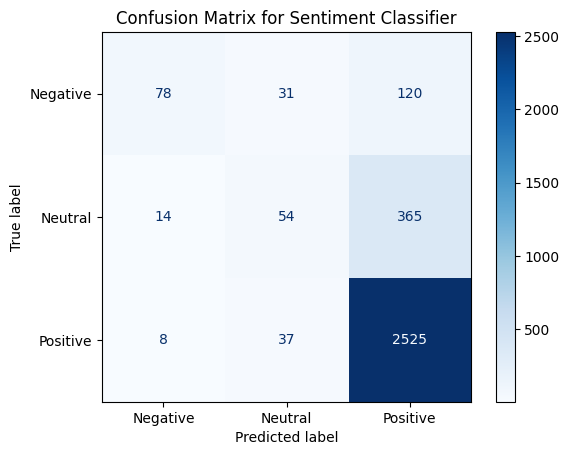

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict sentiment on test data
y_pred = clf.predict(X_test_vec)

# Create and plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test_vec,
    y_test,
    display_labels=clf.classes_,
    cmap=plt.cm.Blues,
    normalize=None  # or "true" for normalized percentages
)

plt.title("Confusion Matrix for Sentiment Classifier")
plt.show()


In [9]:
# ------------------------------------------
# 5. PREDICT SENTIMENT FOR ALL REVIEWS
# ------------------------------------------
df['Predicted_Sentiment'] = clf.predict(tfidf.transform(df['Text']))
df['Predicted_Sentiment'] 

0        Positive
1        Positive
2        Positive
3        Positive
4        Positive
           ...   
16151    Positive
16152    Positive
16153    Positive
16154    Positive
16155    Positive
Name: Predicted_Sentiment, Length: 16156, dtype: object

In [10]:
# ------------------------------------------
# 6. COMPUTE LOCATION-LEVEL FEATURES
# ------------------------------------------
location_group = df.groupby('Location_Name')


In [11]:
# Combine reviews for TF-IDF similarity
location_text = location_group['Text'].apply(lambda x: " ".join(x))


In [12]:
# Average predicted sentiment score (numerical)
sentiment_map = {"Negative": -1, "Neutral": 0, "Positive": 1}
location_sentiment_score = location_group['Predicted_Sentiment'].apply(
    lambda x: np.mean([sentiment_map[s] for s in x])
)

In [13]:
# New DataFrame for recommender
loc_df = pd.DataFrame({
    "Text": location_text,
    "Sentiment_Score": location_sentiment_score
})
loc_df

,Text,Sentiment_Score
Location_Name,,
Abhayagiri Dagaba,Totally breathtaking. This huge stupa is an in...,0.937500
Ambewela Farms,On the way to Hortons plain this is beautiful ...,0.860294
Ariyapala Mask Museum,"You get to see different type of mask, very un...",0.857143
Arugam Bay,I had a manicure here and it really was profes...,0.807487
Baker's Falls,"Baker falls is an amazing natural site, but it...",0.918919
...,...,...
Udawalawe National Park,The entrance is very expensive comparing to sr...,0.966443
Udawattekele Sanctuary,We went in there and yes it is jungle in the c...,0.925439
Victoria Park of Nuwara Eliya,A large expansive park in the heart of Nuwara ...,0.698113


In [14]:
# ------------------------------------------
# 7. BUILD SIMILARITY MATRIX
# ------------------------------------------
loc_tfidf = tfidf.fit_transform(loc_df["Text"])
cosine_sim = cosine_similarity(loc_tfidf, loc_tfidf)
cosine_sim


array([[1.        , 0.01233691, 0.03817258, ..., 0.05661443, 0.03492727,
        0.16212203],
       [0.01233691, 1.        , 0.01789659, ..., 0.09972587, 0.03811165,
        0.01025721],
       [0.03817258, 0.01789659, 1.        , ..., 0.04700084, 0.0128976 ,
        0.21611908],
       ...,
       [0.05661443, 0.09972587, 0.04700084, ..., 1.        , 0.08269317,
        0.06921579],
       [0.03492727, 0.03811165, 0.0128976 , ..., 0.08269317, 1.        ,
        0.01112661],
       [0.16212203, 0.01025721, 0.21611908, ..., 0.06921579, 0.01112661,
        1.        ]], shape=(76, 76))

In [15]:
import networkx as nx

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


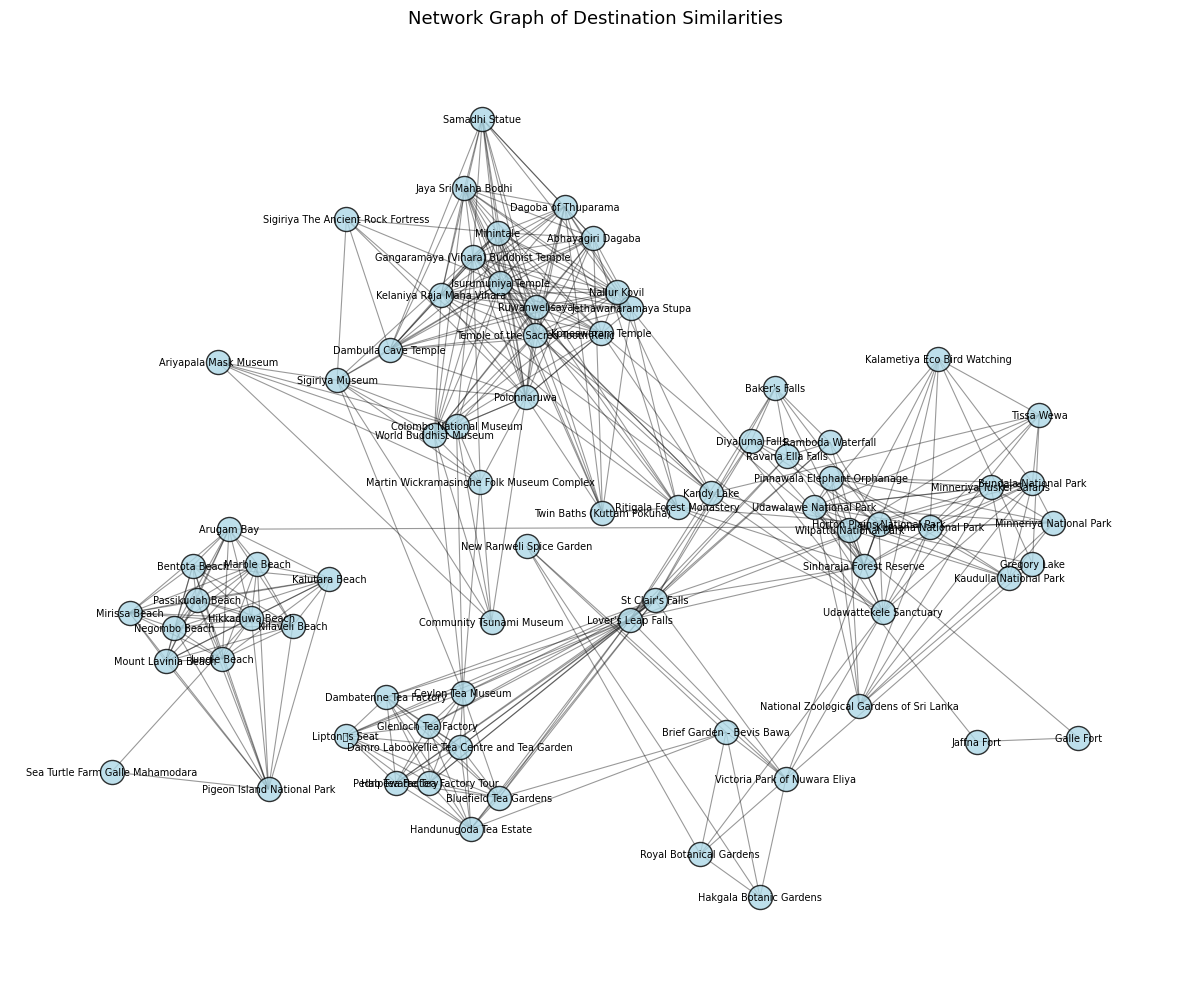

In [46]:
# ----------------------------
# 6. NETWORK GRAPH OF LOCATION SIMILARITIES
# ----------------------------
locations = loc_df.index.tolist()
num_locations = len(locations)

G = nx.Graph()
for i in range(num_locations):
    for j in range(i+1, num_locations):
        if cosine_sim[i, j] > 0.15:  # only strong similarities
            G.add_edge(locations[i], locations[j], weight=cosine_sim[i, j])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

nx.draw_networkx_nodes(G, pos,
                       node_size=300,
                       node_color='lightblue',
                       edgecolors='k',
                       alpha=0.8)

nx.draw_networkx_edges(G, pos,
                       width=0.8,
                       alpha=0.4)

nx.draw_networkx_labels(G, pos,
                        font_size=7,
                        font_color='black')

plt.title("Network Graph of Destination Similarities", fontsize=13, pad=10)
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------
# 8. HYBRID RECOMMENDER FUNCTION
# ------------------------------------------
def recommend(location, n=5):
    if location not in loc_df.index:
        return f"Location '{location}' not found."

    idx = loc_df.index.get_loc(location)
    # similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # rank by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip itself
    sim_scores = sim_scores[1:n+10]
    # calculate hybrid score:
    # 0.7 * similarity + 0.3 * sentiment score
    ranked = []
    for i, sim in sim_scores:
        final_score = 0.7 * sim + 0.3 * loc_df.iloc[i]["Sentiment_Score"]
        ranked.append((loc_df.index[i], final_score))

    ranked = sorted(ranked, key=lambda x: x[1], reverse=True)

    # return top N
    return [loc for loc, score in ranked[:n]]


In [ ]:
# ------------------------------------------
# 9.Testing Multiple Locations 
# ------------------------------------------
print("\nRecommendations for Arugam Bay:")
print(recommend("Arugam Bay", n=5))



Recommendations for Arugam Bay:
['Mirissa Beach', 'Hikkaduwa Beach', 'Bentota Beach', 'Passikudah Beach', 'Nilaveli Beach']


In [48]:
print("\nRecommendations for Diyaluma Falls:")
print(recommend("Diyaluma Falls", n=5))


Recommendations for Diyaluma Falls:
['Ravana Ella Falls', "Lover's Leap Falls", 'Ramboda Waterfall', "St Clair's Falls", "Baker's Falls"]


In [50]:
print("\nRecommendations for Arugam Bay:")
print(recommend("Arugam Bay", n=5))


Recommendations for Arugam Bay:
['Mirissa Beach', 'Hikkaduwa Beach', 'Bentota Beach', 'Passikudah Beach', 'Nilaveli Beach']


In [49]:
# Consistency of Similarity Scoring 
loc_df.loc[recommendations][['Sentiment_Score']]
loc_df.loc[recommendations]['Text']  # inspect review similarity


Location_Name
Mirissa Beach       It's a beautiful beach and clean surrounding. ...
Hikkaduwa Beach     Love the sea turtles and that thereÂs an opti...
Bentota Beach       Beautiful beach so clean.  Golden sand and a b...
Passikudah Beach    The beach is wide, the sand is warm and the In...
Nilaveli Beach      We stayed at the Moon Isle Beach Bungalows on ...
Name: Text, dtype: object

In [ ]:
# Example query for Diyaluma Falls
print("\nRecommendations for Diyaluma Falls:")
print(recommend("Diyaluma Falls", n=5))


Recommendations for Diyaluma Falls:
['Ravana Ella Falls', "Lover's Leap Falls", 'Ramboda Waterfall', "St Clair's Falls", "Baker's Falls"]


In [ ]:
# Comparison with Known Popular Destinations 
popular_destinations = ["Nilaveli Beach", "Passikudah", "Trincomalee", "Unawatuna"]
recommendations = recommend("Arugam Bay", n=5)
matching = set(recommendations) & set(popular_destinations)
print(f"Matching with popular destinations: {matching}")

Matching with popular destinations: {'Nilaveli Beach'}
